Table of contents
* 1. Pre-processing
   * 1.1 Import packages
   * 1.2 Set up Data Augmentation
   * 1.3 Split into Training & Testing sets
<br>
<br>
* 2. Modeling
    * 2.1 ResNet Model
    * 2.2 EfficientNet Model- Basic
    * 2.3 EfficientNet Model- Tuning
<br>
<br>
* 3. Calibration and Threshold Tuning 
   * 3.1 Temperature Scaling
   * 3.2 Threshold Tuning
   * 3.3 Sample Predictions

# 1. Pre-processing

1.1 Import packages

In [1]:
# Import packages
import os
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models
import torch.optim as optim
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import confusion_matrix, precision_score, recall_score, fbeta_score


In [2]:
#setup directory
data_dir = "./tpc-imgs"

1.2 Set up Data Augmentation

In [3]:
IMG_SIZE = 224

# Data Augmentation for training set

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([transforms.RandomAffine(0, shear=2)], p=0.15),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.05)], p=0.10),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])


])

# Data Augmentation for testing set
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


1.3 Split into Training & Testing sets

In [4]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir)

# Split indices
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# setup DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=3)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=3)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Modeling

2.1 ResNet Model

In [5]:
# Setup resnet model
modelR = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelR.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = modelR.fc.in_features
modelR.fc = nn.Linear(num_features, 2)

modelR.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelR.fc.parameters(), lr=1e-4)


In [6]:
%%time
# Run resnet model
epochs = 5 #initially ran 15 but switched to 5 for rerun to cut down on time

for epoch in range(epochs):
    modelR.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelR(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelR.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelR(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

Epoch 1/5 - Loss: 0.6712
Validation Accuracy: 0.6280
Confusion Matrix:
 [[722 475]
 [340 654]]
Recall:    0.6579
Precision: 0.5793
F2 Score:  0.6405
Epoch 2/5 - Loss: 0.6274
Validation Accuracy: 0.6668
Confusion Matrix:
 [[819 378]
 [352 642]]
Recall:    0.6459
Precision: 0.6294
F2 Score:  0.6425
Epoch 3/5 - Loss: 0.6074
Validation Accuracy: 0.6837
Confusion Matrix:
 [[867 330]
 [363 631]]
Recall:    0.6348
Precision: 0.6566
F2 Score:  0.6391
Epoch 4/5 - Loss: 0.5902
Validation Accuracy: 0.6947
Confusion Matrix:
 [[927 270]
 [399 595]]
Recall:    0.5986
Precision: 0.6879
F2 Score:  0.6145
Epoch 5/5 - Loss: 0.5781
Validation Accuracy: 0.7033
Confusion Matrix:
 [[914 283]
 [367 627]]
Recall:    0.6308
Precision: 0.6890
F2 Score:  0.6416
CPU times: total: 2h 26min 27s
Wall time: 22min 22s


2.2 EfficientNet Model- Basic

In [7]:
# Setup efficientnet model
modelE = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelE.parameters():
    param.requires_grad = False

# Replace classifier
num_features = modelE.classifier[1].in_features
modelE.classifier[1] = nn.Linear(num_features, 2)

modelE.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE.classifier[1].parameters(), lr=1e-4)

In [8]:
%%time
#Run efficientnet model

for epoch in range(5): #Initially ran 15 but switched to 5 for rerun to cut down on time
    modelE.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelE(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelE.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelE(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")


Epoch 1/5 - Loss: 0.6716
Validation Accuracy: 0.6518
Confusion Matrix:
 [[920 277]
 [486 508]]
Recall:    0.5111
Precision: 0.6471
F2 Score:  0.5335
Epoch 2/5 - Loss: 0.6244
Validation Accuracy: 0.6878
Confusion Matrix:
 [[949 248]
 [436 558]]
Recall:    0.5614
Precision: 0.6923
F2 Score:  0.5834
Epoch 3/5 - Loss: 0.5994
Validation Accuracy: 0.7033
Confusion Matrix:
 [[984 213]
 [437 557]]
Recall:    0.5604
Precision: 0.7234
F2 Score:  0.5868
Epoch 4/5 - Loss: 0.5842
Validation Accuracy: 0.7161
Confusion Matrix:
 [[988 209]
 [413 581]]
Recall:    0.5845
Precision: 0.7354
F2 Score:  0.6095
Epoch 5/5 - Loss: 0.5729
Validation Accuracy: 0.7193
Confusion Matrix:
 [[979 218]
 [397 597]]
Recall:    0.6006
Precision: 0.7325
F2 Score:  0.6230
CPU times: total: 2h 18min 32s
Wall time: 22min 46s


2.3 EfficientNet Model- Tuning

In [9]:
# Create Functions for use in tuning better efficientNet Model

def mixup_data(x, y, alpha=0.4):
    """ Perform Mixup augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    return mixed_x, y, y[index], lam


def cutmix_data(x, y, alpha=0.4):
    """ Perform CutMix augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size).to(x.device)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y, y[index], lam


def mixup_cutmix_criterion(criterion, preds, y_a, y_b, lam):
    """Compute the loss for Mixup or CutMix augmented samples."""
    
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


def compute_metrics(model, dataloader, device, toxic_class=1):
    """Compute confusion matrix, precision, recall, and F2 score for a model.
       Runs the model on the provided dataloader and collects predictions and labels to compute classification metrics."""
    
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, pos_label=toxic_class)
    precision = precision_score(all_labels, all_preds, pos_label=toxic_class)
    f2 = fbeta_score(all_labels, all_preds, beta=2, pos_label=toxic_class)

    return cm, precision, recall, f2


# Training Loop
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """Train the model for a single epoch with optional Mixup/CutMix augmentation.
       Randomly applies Mixup or CutMix to each batch with equal probability.
       Computes loss, performs backpropagation, and tracks accuracy."""
    
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        rand_val = np.random.rand()

        if rand_val < 0.25:
            images_mixed, y_a, y_b, lam = mixup_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        elif rand_val < 0.50:
            images_mixed, y_a, y_b, lam = cutmix_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


# Validation Loop
def validate(model, dataloader, criterion, device):
    """Evaluate the model on a validation dataset.
       Computes loss and accuracy without performing gradient updates."""
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
# Setup efficientnet model
modelE2 = models.efficientnet_b0(weights="IMAGENET1K_V1")
num_features = modelE2.classifier[1].in_features
modelE2.classifier[1] = nn.Linear(num_features, len(full_dataset.classes))

modelE2 = modelE2.to(device)

# Set Criterion
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.3]).to(device), label_smoothing=0.05)


In [11]:
%%time
# Run EfficientNet Model
# Phase 1 - Train classifier Head
for param in modelE2.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(modelE2.classifier[1].parameters(), lr=2e-4)

def warmup(epoch):
    """Linear warmup schedule for learning rate scaling.
       Gradually increases the learning rate during the first few epochs
       to stabilize early training."""
    
    return min(1.0, (epoch + 1) / 3)

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

print("=== Phase 1: Training classifier head ===")
for epoch in range(6):
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 3:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/6 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")


# Phase 2 - Unfreeze Top 30%
for name, param in modelE2.named_parameters():
    if "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, modelE2.parameters()), lr=3e-5)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e+1)/2))
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=2, eta_min=1e-6)

print("\n=== Phase 2: Unfreezing top layers ===")
for epoch in range(4):
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 2:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/4 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")


# Phase 3 - Full Fine Tune
for param in modelE2.parameters():
    param.requires_grad = True

optimizer = optim.Adam(modelE2.parameters(), lr=1e-5)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=5e-6)

print("\n=== Phase 3: Full fine-tuning ===")
for epoch in range(10):
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/10 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")


=== Phase 1: Training classifier head ===

Epoch 1/6 | Train Acc: 0.5454 | Val Acc: 0.6248
Confusion Matrix:
 [[633 564]
 [258 736]]
Recall:    0.7404
Precision: 0.5662
F2 Score:  0.6975

Epoch 2/6 | Train Acc: 0.6131 | Val Acc: 0.6828
Confusion Matrix:
 [[798 399]
 [296 698]]
Recall:    0.7022
Precision: 0.6363
F2 Score:  0.6880

Epoch 3/6 | Train Acc: 0.6422 | Val Acc: 0.7106
Confusion Matrix:
 [[904 293]
 [341 653]]
Recall:    0.6569
Precision: 0.6903
F2 Score:  0.6633

Epoch 4/6 | Train Acc: 0.6504 | Val Acc: 0.7330
Confusion Matrix:
 [[856 341]
 [244 750]]
Recall:    0.7545
Precision: 0.6874
F2 Score:  0.7401

Epoch 5/6 | Train Acc: 0.6689 | Val Acc: 0.7389
Confusion Matrix:
 [[890 307]
 [265 729]]
Recall:    0.7334
Precision: 0.7037
F2 Score:  0.7273

Epoch 6/6 | Train Acc: 0.6807 | Val Acc: 0.7257
Confusion Matrix:
 [[892 305]
 [296 698]]
Recall:    0.7022
Precision: 0.6959
F2 Score:  0.7009

=== Phase 2: Unfreezing top layers ===

Epoch 1/4 | Train Acc: 0.6561 | Val Acc: 0.7339

In [12]:
torch.save(modelE2.state_dict(), "model_final.pth")
print("Saved model to model_final.pth")

Saved model to model_final.pth


# 3. Calibration and Threshold Tuning

3.1 Temperature Scaling

In [13]:
%%time
# Model calibration using temperature scaling

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds a learnable temperature parameter for post-training calibration.
       Temperature scaling adjusts the confidence of logits without changing the model's predicted class ordering."""
    
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


def calibrate_temperature(model, dataloader, device):
    """Fit a temperature parameter to calibrate model confidence.
       Uses validation logits and labels to optimize temperature."""
    
    model.eval()
    nll_criterion = nn.CrossEntropyLoss()

    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    temp_model = ModelWithTemperature(model).to(device)
    optimizer = optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

    def eval_closure():
        optimizer.zero_grad()
        loss = nll_criterion(logits / temp_model.temperature, labels)
        loss.backward()
        return loss

    optimizer.step(eval_closure)
    return temp_model

print("\n=== Calibrating model with temperature scaling ===")
modelE2 = calibrate_temperature(modelE2, val_loader, device)
print("Learned temperature:", modelE2.temperature.item())


# Threshold tuning on calibrated model
def tune_threshold(model, dataloader, device, toxic_class=1):
    """Find the optimal classification threshold based on F2 score.
       Sweeps thresholds from 0.10 to 0.90 and selects the one that maximizes the F2 score, which emphasizes recall."""
    
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, toxic_class]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = torch.tensor(all_probs).numpy()
    all_labels = torch.tensor(all_labels).numpy()

    best_t, best_f2, best_recall = 0.5, -1.0, -1.0
    for t in [i / 100 for i in range(10, 91, 2)]:  # 0.10 to 0.90 step 0.02
        preds = (all_probs >= t).astype(int)
        recall = recall_score(all_labels, preds, pos_label=toxic_class)
        f2 = fbeta_score(all_labels, preds, beta=2, pos_label=toxic_class)
        if f2 > best_f2:
            best_f2, best_t, best_recall = f2, t, recall

    return best_t, best_f2, best_recall

best_t, best_f2, best_recall = tune_threshold(modelE2, val_loader, device)
print(f"\n=== Threshold tuning (calibrated model) ===")
print(f"Best threshold: {best_t:.2f}")
print(f"Best F2:        {best_f2:.4f}")
print(f"Recall at best: {best_recall:.4f}")




=== Calibrating model with temperature scaling ===
Learned temperature: 0.7294372916221619

=== Threshold tuning (calibrated model) ===
Best threshold: 0.20
Best F2:        0.9008
Recall at best: 0.9779
CPU times: total: 9min 16s
Wall time: 1min 41s


In [14]:
with open("temperature.txt", "w") as f:
    f.write(str(modelE2.temperature.item()))
print("Saved temperature to temperature.txt")


Saved temperature to temperature.txt


In [60]:
%%time
#load model to apply calibration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds the fixed learned temperature parameter above"""
    def __init__(self, model, temperature):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.tensor([temperature]))

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature



# Load Trained model and apply calibration

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier head
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)   # toxic vs clean

# Load trained weights
model.load_state_dict(torch.load("model_final.pth", map_location=device))

# Wrap with temperature scaling
temperature = modelE2.temperature.item()
model = ModelWithTemperature(model, temperature).to(device)
model.eval()


# Preprocessing Pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
])


CPU times: total: 281 ms
Wall time: 242 ms


3.2 Threshold Tuning

In [61]:
def collect_logits_and_labels(model, dataloader, device):
    """Run model to return logits + labels."""
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    return torch.cat(all_logits), torch.cat(all_labels)

def compute_threshold_metrics(logits, labels, thresholds):
    """Compute precision, recall, and F2 for a list of thresholds."""
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    labels = labels.numpy()

    precisions, recalls, f2_scores = [], [], []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(labels, preds, zero_division=0))
        recalls.append(recall_score(labels, preds))
        f2_scores.append(fbeta_score(labels, preds, beta=2))

    return precisions, recalls, f2_scores

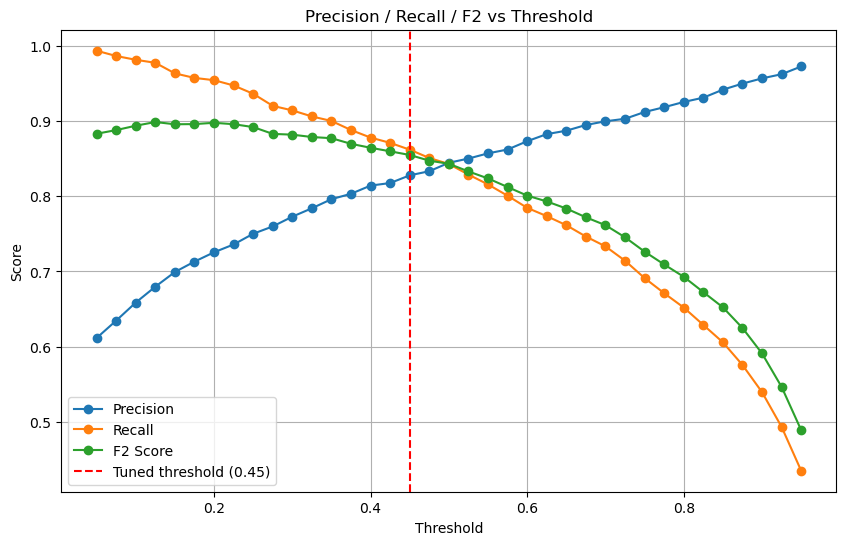

CPU times: total: 4min 41s
Wall time: 52.5 s


In [62]:
%%time
import matplotlib.pyplot as plt

# 1. Collect logits once
logits, labels = collect_logits_and_labels(modelE2, val_loader, device)

# 2. Apply temperature scaling
T = modelE2.temperature.item()
logits_eval = logits / T
#logits_eval = logits #use this variable to test model without applying temperature scaling

# 3. Define thresholds for plotting
thresholds_plot = np.linspace(0.05, 0.95, 37)

# 4. Compute metrics for plot
precisions, recalls, f2_scores = compute_threshold_metrics(
    logits_eval, labels, thresholds_plot)


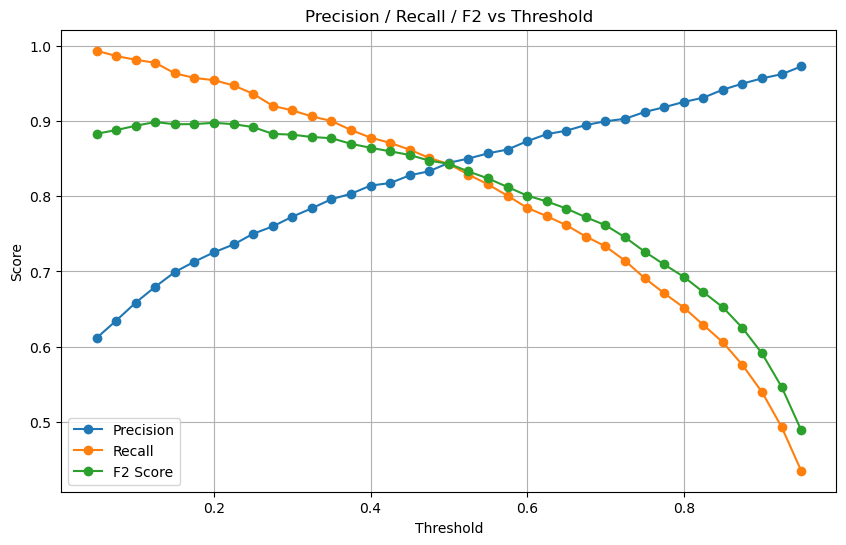

In [67]:
# 5. Plot metrics
plt.figure(figsize=(10,6))
plt.plot(thresholds_plot, precisions, label="Precision", marker="o")
plt.plot(thresholds_plot, recalls, label="Recall", marker="o")
plt.plot(thresholds_plot, f2_scores, label="F2 Score", marker="o")

#plt.axvline(0.40, color="red", linestyle="--", label="Tuned threshold (0.40)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F2 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
best_idx = np.argmax(f2_scores)
print(f"Best F2 threshold: {thresholds_plot[best_idx]:.2f} | F2={f2_scores[best_idx]:.4f}")

# Find thresholds where precision >= 0.70 AND recall >= 0.90
candidates = [
    (t, p, r) for t, p, r in zip(thresholds_plot, precisions, recalls)
    if p >= 0.7000 and r >= 0.8999
]

if candidates:
    print("\nBalanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):")
    for t, p, r in candidates:
        print(f"Threshold {t:.2f} | Recall={r:.3f} | Precision={p:.3f}")
else:
    print("\nNo threshold meets precision ≥ 0.7000 and recall ≥ 0.9000 simultaneously.")

Best F2 threshold: 0.12 | F2=0.8990

Balanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):
Threshold 0.17 | Recall=0.958 | Precision=0.713
Threshold 0.20 | Recall=0.955 | Precision=0.726
Threshold 0.22 | Recall=0.948 | Precision=0.736
Threshold 0.25 | Recall=0.937 | Precision=0.750
Threshold 0.27 | Recall=0.921 | Precision=0.760
Threshold 0.30 | Recall=0.914 | Precision=0.773
Threshold 0.32 | Recall=0.906 | Precision=0.784
Threshold 0.35 | Recall=0.900 | Precision=0.796


In [64]:
# Loop through thresholds .30 - .50 to receive metrics

thresholds_zoom = [round(t, 2) for t in np.arange(0.30, 0.501, 0.01)]

probs = torch.softmax(logits_eval, dim=1)[:, 1].numpy()
labels_np = labels.numpy()

for th in thresholds_zoom:
    preds = (probs >= th).astype(int)

    cm = confusion_matrix(labels_np, preds)
    precision = precision_score(labels_np, preds, zero_division=0)
    recall = recall_score(labels_np, preds)
    f2 = fbeta_score(labels_np, preds, beta=2)

    print(f"Threshold: {th:.2f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F2: {f2:.4f}")
    print("-" * 40)


Threshold: 0.30
Confusion Matrix:
 [[930 267]
 [ 85 909]]
Precision: 0.7730 | Recall: 0.9145 | F2: 0.8822
----------------------------------------
Threshold: 0.31
Confusion Matrix:
 [[935 262]
 [ 90 904]]
Precision: 0.7753 | Recall: 0.9095 | F2: 0.8790
----------------------------------------
Threshold: 0.32
Confusion Matrix:
 [[942 255]
 [ 92 902]]
Precision: 0.7796 | Recall: 0.9074 | F2: 0.8786
----------------------------------------
Threshold: 0.33
Confusion Matrix:
 [[953 244]
 [ 93 901]]
Precision: 0.7869 | Recall: 0.9064 | F2: 0.8797
----------------------------------------
Threshold: 0.34
Confusion Matrix:
 [[963 234]
 [ 96 898]]
Precision: 0.7933 | Recall: 0.9034 | F2: 0.8790
----------------------------------------
Threshold: 0.35
Confusion Matrix:
 [[968 229]
 [ 99 895]]
Precision: 0.7963 | Recall: 0.9004 | F2: 0.8775
----------------------------------------
Threshold: 0.36
Confusion Matrix:
 [[974 223]
 [101 893]]
Precision: 0.8002 | Recall: 0.8984 | F2: 0.8769
------------

3.3 Sample Predictions

In [68]:
# function to predict image toxicity

THRESHOLD = 0.35   # tuned threshold (picked for recall above 90% and FN below 100)

def predict_image(image_path):
    """Predict toxicity for a single image using the tuned threshold."""
    
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    toxic_prob = probs[1].item()
    prediction = 1 if toxic_prob >= THRESHOLD else 0

    return {
        "prediction": "TOXIC" if prediction == 1 else "Non-Toxic",
        "toxic_probability": toxic_prob,
        "threshold_used": THRESHOLD
    }

In [69]:
# Test example
result = predict_image("tpc-imgs\\nontoxic_images\\003\\001.jpg")
print(result)


{'prediction': 'TOXIC', 'toxic_probability': 0.43785351514816284, 'threshold_used': 0.35}


In [72]:
%%time
# function to batch predict image toxicity

THRESHOLD = 0.35  # tuned threshold (picked for recall above 90% and FN below 100)

def predict_folder(folder_path, save_toxic=False):
    """Predict toxicity for a each image in a folder using the tuned threshold."""
    results = []
    toxic_dir = os.path.join(folder_path, "toxic_detected")

    if save_toxic and not os.path.exists(toxic_dir):
        os.makedirs(toxic_dir)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            continue

        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]

        toxic_prob = probs[1].item()
        prediction = 1 if toxic_prob >= THRESHOLD else 0
        label = "TOXIC" if prediction == 1 else "CLEAN"

        # Save toxic images if requested
        if save_toxic and prediction == 1:
            img.save(os.path.join(toxic_dir, filename))

        results.append({
            "filename": filename,
            "prediction": label,
            "toxic_probability": toxic_prob,
            "threshold": THRESHOLD
        })

    return pd.DataFrame(results)

# Run batch predictions
folder = "tpc-imgs\\toxic_images\\000"   # 
df = predict_folder(folder, save_toxic=True)

df.to_csv("batch_predictions.csv", index=False)
print("Saved results to batch_predictions.csv")
print(df.head())

Saved results to batch_predictions.csv
  filename prediction  toxic_probability  threshold
0  000.jpg      TOXIC           0.939022       0.35
1  001.jpg      TOXIC           0.876400       0.35
2  002.jpg      TOXIC           0.604465       0.35
3  003.jpg      TOXIC           0.791816       0.35
4  004.jpg      TOXIC           0.947779       0.35
CPU times: total: 4min 59s
Wall time: 52.7 s


In [73]:
# Test example
print(df.tail(10))

    filename prediction  toxic_probability  threshold
990  990.jpg      TOXIC           0.402719       0.35
991  991.jpg      TOXIC           0.958106       0.35
992  992.jpg      TOXIC           0.932594       0.35
993  993.jpg      TOXIC           0.975829       0.35
994  994.jpg      TOXIC           0.366290       0.35
995  995.jpg      TOXIC           0.995295       0.35
996  996.jpg      TOXIC           0.992592       0.35
997  997.jpg      TOXIC           0.843148       0.35
998  998.jpg      TOXIC           0.394614       0.35
999  999.jpg      TOXIC           0.992252       0.35
